# Financial News Sentiment Analysis with BERT
Fine-tuning BERT to classify financial news into **positive / negative / neutral**

**Dataset:** Financial PhraseBank (Malo et al., 2014)  
**Model:** bert-base-uncased (HuggingFace Transformers)  
**Task:** 3-class sentiment classification

## 1. 安裝與載入套件

In [12]:
# 安裝必要套件（第一次執行時需要）
#!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn

In [13]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 設定隨機種子確保可重現性
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. 資料載入與探索（EDA）

In [14]:
# CSV 載入
df = pd.read_csv('all-data.csv', 
                 encoding='latin-1', 
                 header=None, 
                 names=['sentiment', 'text'])

# 轉換 label 為數字
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

print(f'資料集大小: {len(df)} 筆')
print(f'\n類別分佈:')
print(df['sentiment'].value_counts())
df.head()

資料集大小: 4846 筆

類別分佈:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


,sentiment,text,label
0,neutral,"According to Gran , the company has no plans t...",1
1,neutral,Technopolis plans to develop in stages an area...,1
2,negative,The international electronic industry company ...,0
3,positive,With the new production plant the company woul...,2
4,positive,According to the company 's updated strategy f...,2


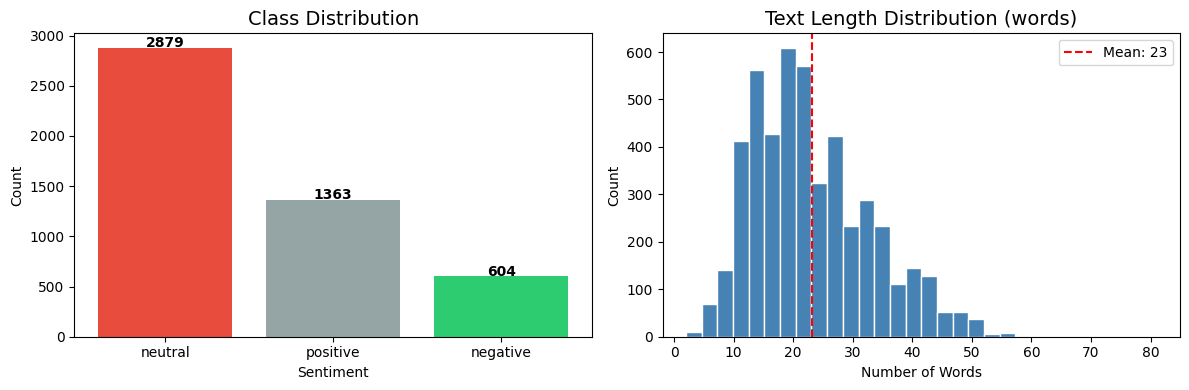


文字長度統計:
count    4846.0
mean       23.1
std        10.0
min         2.0
25%        16.0
50%        21.0
75%        29.0
max        81.0
Name: text_length, dtype: float64


In [15]:
# 類別分佈
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 長條圖
counts = df['sentiment'].value_counts()
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 文字長度分佈
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
axes[1].hist(df['text_length'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Text Length Distribution (words)', fontsize=14)
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Count')
axes[1].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['text_length'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n文字長度統計:")
print(df['text_length'].describe().round(1))

## 3. 資料預處理

In [16]:
# 超參數設定
MAX_LEN = 128       # BERT 最大輸入長度
BATCH_SIZE = 16
EPOCHS = 4
LEARNING_RATE = 2e-5
MODEL_NAME = 'ProsusAI/finbert'  # 金融領域預訓練模型

# 載入 BERT Tokenizer
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

# 示範 tokenizer 輸出
sample = df['text'][0]
print(f'\n範例句子: {sample}')
tokens = tokenizer.tokenize(sample)
print(f'Tokenized: {tokens[:15]}...')

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

c:\Users\ned92\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ned92\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

Tokenizer loaded: ProsusAI/finbert

範例句子: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
Tokenized: ['according', 'to', 'gran', ',', 'the', 'company', 'has', 'no', 'plans', 'to', 'move', 'all', 'production', 'to', 'russia']...


c:\Users\ned92\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [17]:
from sklearn.utils.class_weight import compute_class_weight

class FinancialNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }


# 切分資料集：70% train / 15% val / 15% test
X = df['text'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f'Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}')

# 計算類別權重以處理不平衡問題
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f'\n類別權重 (negative / neutral / positive): {class_weights.round(3)}')

# 建立 Dataset 和 DataLoader
train_dataset = FinancialNewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = FinancialNewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = FinancialNewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Train: 3392 | Validation: 727 | Test: 727

類別權重 (negative / neutral / positive): [2.673 0.561 1.185]


## 4. 模型建立

In [18]:
# 載入預訓練 FinBERT，接上 3 分類的輸出層
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)
model = model.to(device)

# 計算模型參數量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# Weighted Loss（處理類別不平衡）
loss_fn = torch.nn.CrossEntropyLoss(weight=weights_tensor)

# Optimizer 和 Scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)
print(f'\nTotal training steps: {total_steps}')

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Total parameters:     109,484,547
Trainable parameters: 109,484,547

Total training steps: 848


## 5. 訓練與評估

In [19]:
def train_epoch(model, loader, optimizer, scheduler, device, loss_fn):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)  # 使用 weighted loss
        loss.backward()

        # Gradient clipping 防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

In [20]:
# 訓練主迴圈
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print('-' * 40)

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn)
    val_loss, val_acc     = evaluate(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}')

    # 儲存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'  ✓ Best model saved (val_acc: {best_val_acc:.4f})')

print(f'\nTraining complete. Best val accuracy: {best_val_acc:.4f}')


Epoch 1/4
----------------------------------------
Train Loss: 1.0313 | Train Acc: 0.6383
Val   Loss: 0.3958 | Val   Acc: 0.8501
  ✓ Best model saved (val_acc: 0.8501)

Epoch 2/4
----------------------------------------
Train Loss: 0.2499 | Train Acc: 0.9051
Val   Loss: 0.3948 | Val   Acc: 0.8707
  ✓ Best model saved (val_acc: 0.8707)

Epoch 3/4
----------------------------------------
Train Loss: 0.1177 | Train Acc: 0.9623
Val   Loss: 0.4485 | Val   Acc: 0.8803
  ✓ Best model saved (val_acc: 0.8803)

Epoch 4/4
----------------------------------------
Train Loss: 0.0613 | Train Acc: 0.9817
Val   Loss: 0.4936 | Val   Acc: 0.8803

Training complete. Best val accuracy: 0.8803


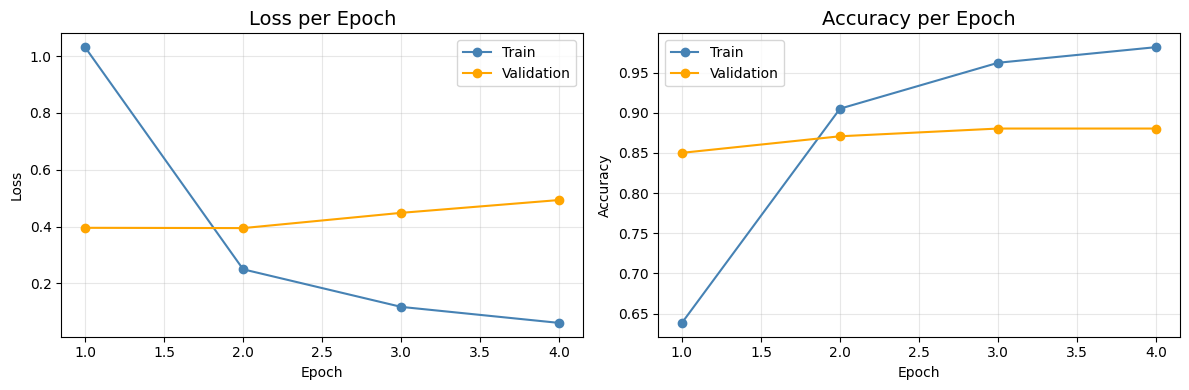

In [21]:
# 畫出 Training Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'],   'o-', label='Validation', color='orange')
axes[0].set_title('Loss per Epoch', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='steelblue')
axes[1].plot(epochs_range, history['val_acc'],   'o-', label='Validation', color='orange')
axes[1].set_title('Accuracy per Epoch', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 結果分析

In [22]:
# 載入最佳模型，在 test set 上評估
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label']

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Classification Report
label_names = ['negative', 'neutral', 'positive']
print('=== Test Set Results ===')
print(f'Accuracy: {accuracy_score(all_labels, all_preds):.4f}')
print(f'F1 Score (weighted): {f1_score(all_labels, all_preds, average="weighted"):.4f}')
print(f'\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=label_names))

=== Test Set Results ===
Accuracy: 0.8666
F1 Score (weighted): 0.8668

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.87      0.84        91
     neutral       0.90      0.89      0.89       432
    positive       0.82      0.82      0.82       204

    accuracy                           0.87       727
   macro avg       0.85      0.86      0.85       727
weighted avg       0.87      0.87      0.87       727



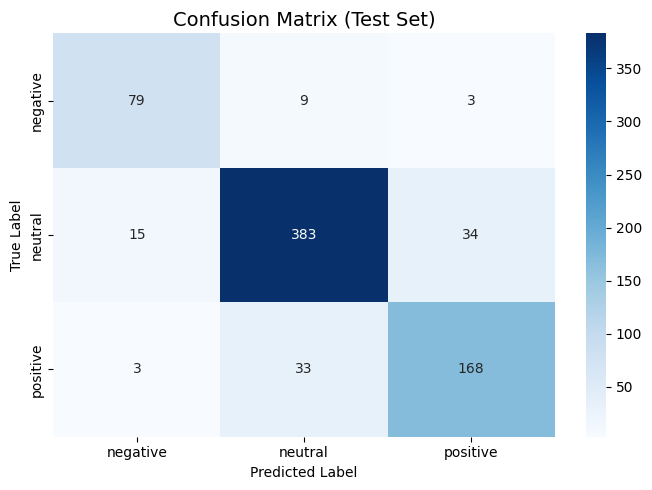

In [23]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix (Test Set)', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# 自訂句子預測
def predict_sentiment(text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()
        pred = probs.argmax()

    label_names = ['negative', 'neutral', 'positive']
    print(f'Text: "{text}"')
    print(f'Prediction: {label_names[pred]} (confidence: {probs[pred]:.2%})')
    print(f'Probabilities → negative: {probs[0]:.2%} | neutral: {probs[1]:.2%} | positive: {probs[2]:.2%}')
    print()


# 測試範例句子
test_sentences = [
    "The company reported record profits and raised its annual forecast.",
    "Operating profit fell to EUR 22.4 mn from EUR 34.2 mn.",
    "The board of directors approved the acquisition of a Finnish company.",
    "Sales volumes increased by 7% compared to the previous year.",
    "The firm announced layoffs affecting 500 employees worldwide."
]

print('=== Custom Prediction Examples ===')
for sentence in test_sentences:
    predict_sentiment(sentence, model, tokenizer, device)

=== Custom Prediction Examples ===
Text: "The company reported record profits and raised its annual forecast."
Prediction: positive (confidence: 99.49%)
Probabilities → negative: 0.33% | neutral: 0.18% | positive: 99.49%

Text: "Operating profit fell to EUR 22.4 mn from EUR 34.2 mn."
Prediction: negative (confidence: 99.57%)
Probabilities → negative: 99.57% | neutral: 0.31% | positive: 0.12%

Text: "The board of directors approved the acquisition of a Finnish company."
Prediction: neutral (confidence: 97.98%)
Probabilities → negative: 0.13% | neutral: 97.98% | positive: 1.90%

Text: "Sales volumes increased by 7% compared to the previous year."
Prediction: positive (confidence: 99.56%)
Probabilities → negative: 0.25% | neutral: 0.18% | positive: 99.56%

Text: "The firm announced layoffs affecting 500 employees worldwide."
Prediction: negative (confidence: 99.40%)
Probabilities → negative: 99.40% | neutral: 0.20% | positive: 0.40%

